# Import Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Preprocessing

In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [4]:
df["preprocessed_dataset"] = df["review"].apply(preprocess_text)

# Vectorization

In [5]:
vectorizer = CountVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["preprocessed_dataset"])

# Train LDA Model

In [6]:
lda = LatentDirichletAllocation(
    n_components=5,  # number of topics
    random_state=42
)

lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

# Display Topics

In [8]:
def display_topics(model, feature_names, num_words):
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-num_words:]]
        print(f"Topic {i+1}: {', '.join(words)}")

In [9]:
feature_names = vectorizer.get_feature_names_out()
display_topics(lda, feature_names, 10)

Topic 1: best, episode, play, role, time, man, good, character, series, film
Topic 2: like, make, movie, scene, love, time, life, character, story, film
Topic 3: film, character, think, watch, great, time, really, like, good, movie
Topic 4: guy, year, know, girl, thing, kid, time, people, like, movie
Topic 5: acting, good, time, plot, make, scene, like, bad, movie, film


#  Visualize Topics

In [10]:
def plot_top_words(model, feature_names, topic_index, top_n=10):
    topic = model.components_[topic_index]
    top_features_ind = topic.argsort()[-top_n:]
    
    top_features = [feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]
    
    plt.figure()
    plt.barh(top_features, weights)
    plt.title(f"Topic {topic_index+1}")
    plt.show()

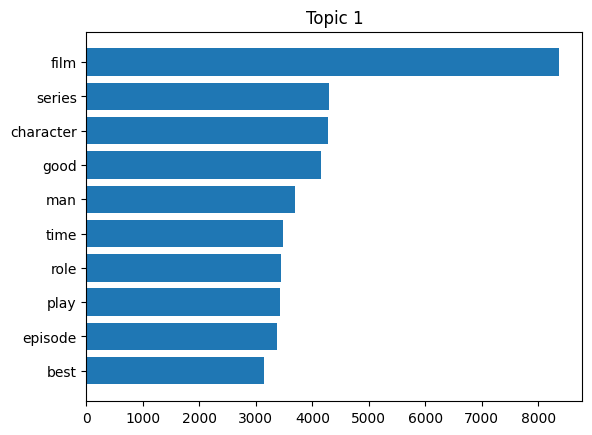

In [11]:
plot_top_words(lda, feature_names, topic_index=0)

# Topic Distribution per Document

In [12]:
topic_distribution = lda.transform(X)

topic_distribution[0]

array([0.36618589, 0.25396407, 0.00174296, 0.28737236, 0.09073473])

In [14]:
df["topic"] = topic_distribution.argmax(axis=1)

df[["preprocessed_dataset", "topic"]].head()

,preprocessed_dataset,topic
0,one reviewer mentioned watching oz episode hoo...,0
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,0
3,basically family little boy jake think zombie ...,3
4,petter mattei love time money visually stunnin...,1


# Interpret Topics

- Topic 1 → movies, film, actor → Movie discussion
- Topic 2 → bad, worst, boring → Negative reviews
- Topic 3 → love, great, amazing → Positive reviews

# NMF (Cleaner Topics)

In [18]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_tfidf = tfidf.fit_transform(df["preprocessed_dataset"])

nmf = NMF(n_components=5, random_state=42)
nmf.fit(X_tfidf)

NMF(n_components=5, random_state=42)

In [19]:
feature_names = tfidf.get_feature_names_out()
display_topics(nmf, feature_names, 10)

Topic 1: play, way, time, young, woman, man, love, life, character, story
Topic 2: really, saw, like, think, time, great, good, seen, watch, movie
Topic 3: actor, watch, saw, best, time, director, good, great, seen, film
Topic 4: worst, horror, plot, thing, guy, good, acting, really, like, bad
Topic 5: dvd, time, comedy, watch, great, funny, season, tv, series, episode


# Compare LDA vs NMF
LDA:
- Probabilistic
- Works on counts

NMF:
- Often cleaner topics
- Works on TF-IDF

# Try Custom Text

- Topic 1: play, way, time, young, woman, man, love, life, character, story
- Topic 2: really, saw, like, think, time, great, good, seen, watch, movie
- Topic 3: actor, watch, saw, best, time, director, good, great, seen, film
- Topic 4: worst, horror, plot, thing, guy, good, acting, really, like, bad
- Topic 5: dvd, time, comedy, watch, great, funny, season, tv, series, episode

In [21]:
text_0 = ["This movie was boring and too long"]

vec_0 = vectorizer.transform(text_0)
topic = lda.transform(vec_0)

print("Topic:", topic.argmax())

Topic: 2


In [33]:
text_1 = ["The story was lovely"]

vec_1 = vectorizer.transform(text_1)
topic = lda.transform(vec_1)

print("Topic:", topic.argmax())

Topic: 1
